In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import log_loss, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from keras.optimizers import SGD, Adam, RMSprop, Nadam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
stroke = pd.read_csv("/content/drive/MyDrive/Project Data Analysis/Bangkit Capstone Project/Dataset/Stroke.csv")

In [4]:
stroke

,sex,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,63.0,0,1,1,4,1,228.69,36.6,1,1
1,1.0,42.0,0,1,1,4,0,105.92,32.5,0,1
2,0.0,61.0,0,0,1,4,1,171.23,34.4,1,1
3,1.0,41.0,1,0,1,3,0,174.12,24.0,0,1
4,1.0,85.0,0,0,1,4,1,186.21,29.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
40905,1.0,38.0,0,0,0,4,1,120.94,29.7,1,0
40906,0.0,53.0,0,0,1,4,0,77.66,40.8,0,0
40907,1.0,32.0,0,0,1,2,0,231.95,33.2,0,0
40908,1.0,42.0,0,0,1,3,0,216.38,34.5,0,0


In [5]:
# 1 = Male, 0 = Female
stroke['sex'].value_counts()


sex
1.0    22710
0.0    18197
Name: count, dtype: int64

In [6]:
# 1 = Yes, 0 = No
stroke['hypertension'].value_counts()


hypertension
0    32162
1     8748
Name: count, dtype: int64

In [7]:
# 1 = Yes, 0 = No
stroke['heart_disease'].value_counts()


heart_disease
0    35685
1     5225
Name: count, dtype: int64

In [8]:
# 1 = Yes, 0 = No
stroke['ever_married'].value_counts()


ever_married
1    33601
0     7309
Name: count, dtype: int64

In [9]:
# 0 = Never_worked, 1 = children, 2 = Govt_job, 3 = Self-employed, 4 = Private
stroke['work_type'].value_counts()

work_type
4    25570
3     9236
2     5588
1      431
0       85
Name: count, dtype: int64

In [10]:
# 1 = Urban,  0 = Rural
stroke['Residence_type'].value_counts()

Residence_type
1    21064
0    19846
Name: count, dtype: int64

In [11]:
# 1 = Smoke, 0 = Never Smoke
stroke['smoking_status'].value_counts()

smoking_status
0    20921
1    19989
Name: count, dtype: int64

In [12]:
# 1 = Stroke, 0 = Not Stroke
stroke['stroke'].value_counts()

stroke
1    20460
0    20450
Name: count, dtype: int64

In [13]:
df = stroke.copy()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40910 entries, 0 to 40909
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sex                40907 non-null  float64
 1   age                40910 non-null  float64
 2   hypertension       40910 non-null  int64  
 3   heart_disease      40910 non-null  int64  
 4   ever_married       40910 non-null  int64  
 5   work_type          40910 non-null  int64  
 6   Residence_type     40910 non-null  int64  
 7   avg_glucose_level  40910 non-null  float64
 8   bmi                40910 non-null  float64
 9   smoking_status     40910 non-null  int64  
 10  stroke             40910 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 3.4 MB


In [15]:
df = df.dropna()

In [16]:
df.duplicated().sum()

0

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40907 entries, 0 to 40909
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sex                40907 non-null  float64
 1   age                40907 non-null  float64
 2   hypertension       40907 non-null  int64  
 3   heart_disease      40907 non-null  int64  
 4   ever_married       40907 non-null  int64  
 5   work_type          40907 non-null  int64  
 6   Residence_type     40907 non-null  int64  
 7   avg_glucose_level  40907 non-null  float64
 8   bmi                40907 non-null  float64
 9   smoking_status     40907 non-null  int64  
 10  stroke             40907 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 3.7 MB


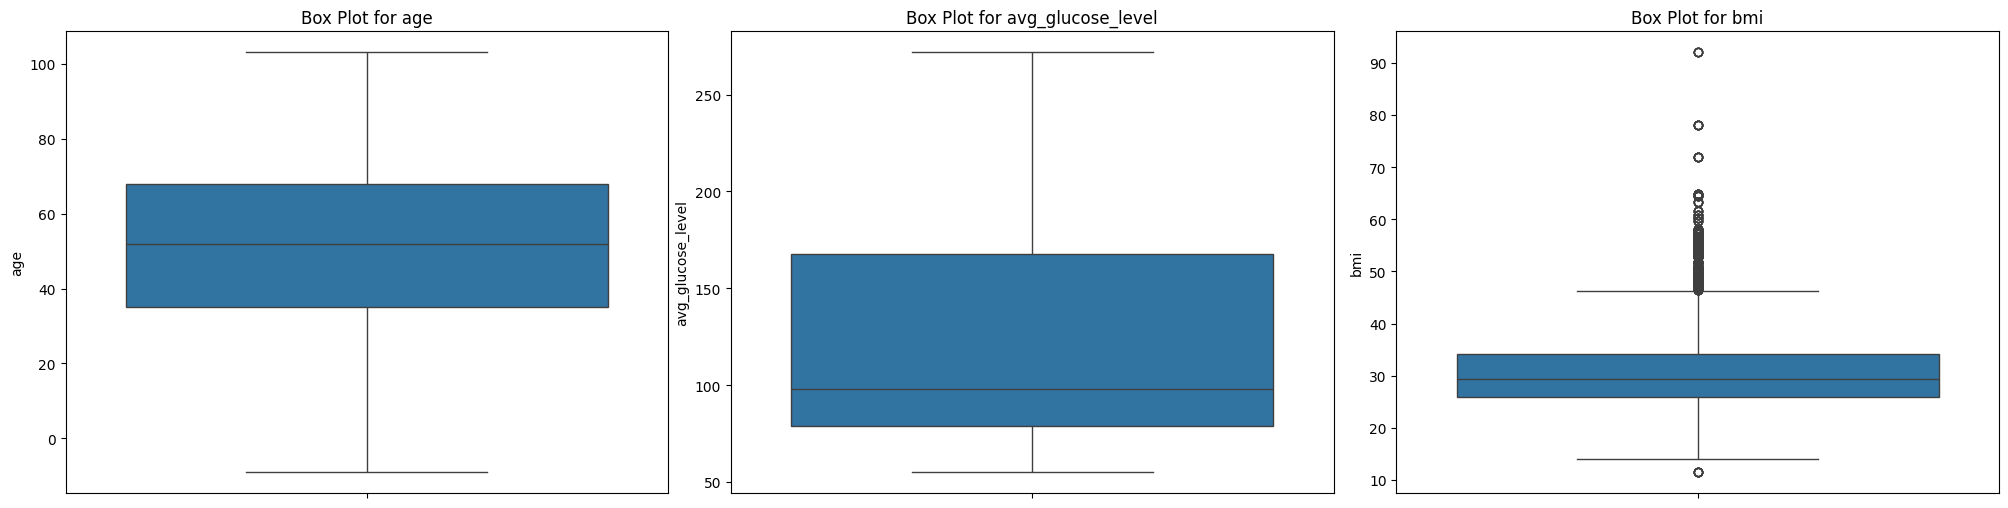

In [18]:
#Identifikasi outlier
numeric_columns = ['age', 'avg_glucose_level', 'bmi']

fig, axs = plt.subplots(ncols=len(numeric_columns), figsize=(20, 5))

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=column, data=df, ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [19]:
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Menghapus outlier dari DataFrame
df_cleaned = remove_outliers(df, numeric_columns)

In [20]:
df = df_cleaned.copy()

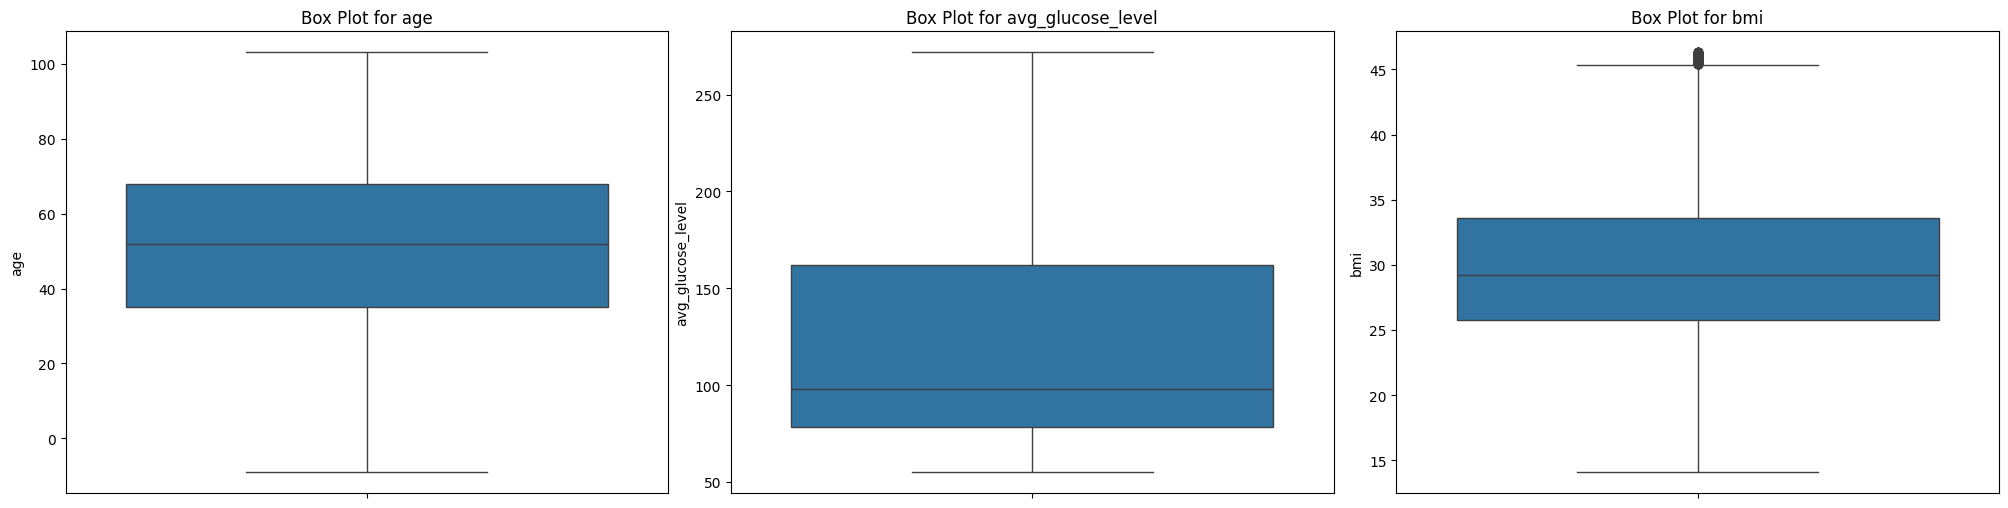

In [21]:
# Pemeriksaan outlier
fig, axs = plt.subplots(ncols=len(numeric_columns), figsize=(20, 5))

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=column, data=df, ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [22]:
X = df.drop(columns=['stroke'])
y = df['stroke']

In [23]:
# Feature selection with randomforest

from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier
rfc = RandomForestClassifier(random_state=42)

# Fit the model to the data
rfc.fit(X, y)

# Get the feature importances
importances = rfc.feature_importances_

# Create a dataframe of feature importances
feature_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=True)

# Print the top 5 most important features
print(feature_importances)


             feature  importance
0                sex    0.008198
9     smoking_status    0.031521
6     Residence_type    0.032212
4       ever_married    0.034846
3      heart_disease    0.038963
1                age    0.040526
5          work_type    0.056978
2       hypertension    0.058636
8                bmi    0.305535
7  avg_glucose_level    0.392584


In [24]:
selected_features = df[['age','avg_glucose_level','bmi','hypertension', 'heart_disease','smoking_status','stroke']]

In [25]:
selected_features.duplicated().sum()

6883

In [26]:
df = selected_features.drop_duplicates()

In [27]:
df

,age,avg_glucose_level,bmi,hypertension,heart_disease,smoking_status,stroke
0,63.0,228.69,36.6,0,1,1,1
1,42.0,105.92,32.5,0,1,0,1
2,61.0,171.23,34.4,0,0,1,1
3,41.0,174.12,24.0,1,0,0,1
4,85.0,186.21,29.0,0,0,1,1
...,...,...,...,...,...,...,...
40903,30.0,79.55,21.1,0,0,1,0
40905,38.0,120.94,29.7,0,0,1,0
40906,53.0,77.66,40.8,0,0,0,0
40908,42.0,216.38,34.5,0,0,0,0


In [28]:
# Membagi data menjadi fitur (X) dan target (y)
X = df.drop(columns=['stroke'])
y = df['stroke']

In [29]:
# Pemisahan data menjadi data pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45545)

In [30]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])


In [31]:
# Membuat model Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, input_dim= 6 ,activation = "relu"),
    tf.keras.layers.Dense(32,activation = "relu"),
    tf.keras.layers.Dense(16,activation = "relu"),
    tf.keras.layers.Dense(8,activation = "relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model.compile(optimizer= Adam(learning_rate = 0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=500, batch_size=60, validation_split = 0.2)


Epoch 1/500
354/354 [==============================] - 8s 14ms/step - loss: 0.5976 - accuracy: 0.6900 - val_loss: 0.5729 - val_accuracy: 0.7142
Epoch 2/500
354/354 [==============================] - 2s 6ms/step - loss: 0.5629 - accuracy: 0.7263 - val_loss: 0.5637 - val_accuracy: 0.7208
Epoch 3/500
354/354 [==============================] - 1s 3ms/step - loss: 0.5492 - accuracy: 0.7315 - val_loss: 0.5483 - val_accuracy: 0.7295
Epoch 4/500
354/354 [==============================] - 1s 3ms/step - loss: 0.5384 - accuracy: 0.7343 - val_loss: 0.5397 - val_accuracy: 0.7327
Epoch 5/500
354/354 [==============================] - 1s 3ms/step - loss: 0.5303 - accuracy: 0.7356 - val_loss: 0.5338 - val_accuracy: 0.7338
Epoch 6/500
354/354 [==============================] - 1s 3ms/step - loss: 0.5233 - accuracy: 0.7396 - val_loss: 0.5253 - val_accuracy: 0.7332
Epoch 7/500
354/354 [==============================] - 1s 3ms/step - loss: 0.5179 - accuracy: 0.7407 - val_loss: 0.5206 - val_accuracy: 0.733

207/207 [==============================] - 1s 3ms/step - loss: 0.0894 - accuracy: 0.9683
Accuracy: 96.83%


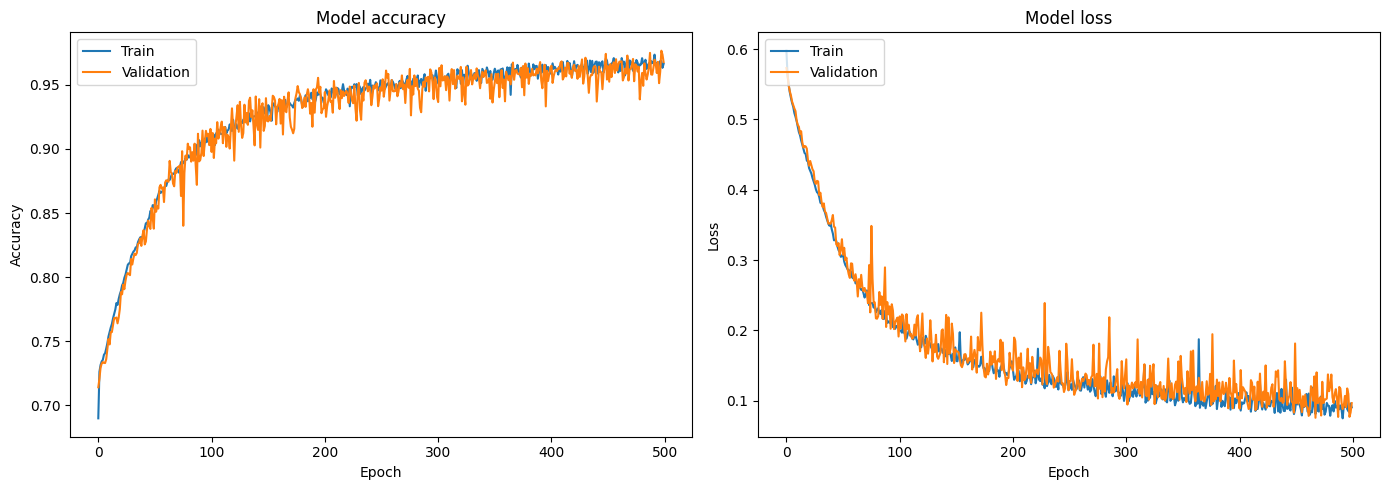

In [32]:
# Evaluasi model pada data testing
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Visualisasi loss dan accuracy
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


207/207 [==============================] - 1s 2ms/step


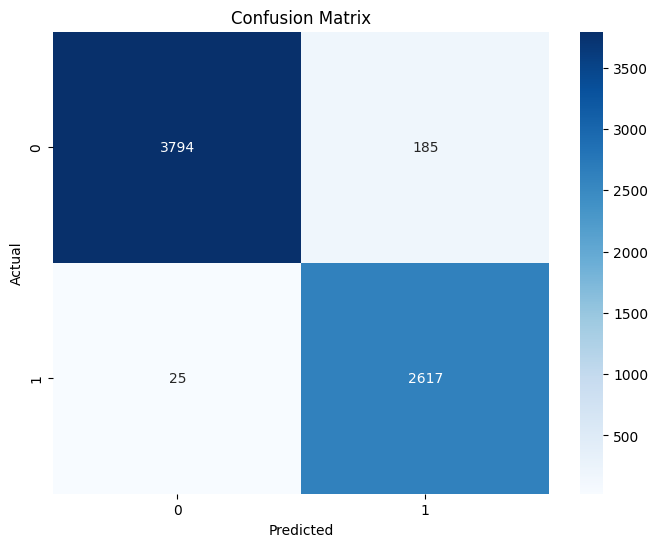

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3979
           1       0.93      0.99      0.96      2642

    accuracy                           0.97      6621
   macro avg       0.96      0.97      0.97      6621
weighted avg       0.97      0.97      0.97      6621



In [33]:
from sklearn.metrics import confusion_matrix, classification_report

# Prediksi pada data testing
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_classes))

In [34]:
y_test.value_counts()

stroke
0    3979
1    2642
Name: count, dtype: int64

In [35]:
# Use model to predict new data

# New data
new_data = {
    "age": 85,
    "avg_glucose_level": 186.21,
    "bmi": 29,
    "hypertension": 0,
    "heart_disease": 0,
    "smoking_status": 1
}

# Convert new data to a dataframe
new_df = pd.DataFrame([new_data])

# Feature scaling
new_df[numeric_columns] = scaler.transform(new_df[numeric_columns])

# Make prediction
prediction = model.predict(new_df)

# Interpret prediction
if prediction[0] > 0.5:
    print("Person is at risk of stroke")
else:
    print("Person is not at risk of stroke")


1/1 [==============================] - 0s 26ms/step
Person is at risk of stroke


In [36]:
# Use model to predict new data

# New data
new_data = {
    "age": 30,
    "avg_glucose_level": 79.55,
    "bmi": 21.1,
    "hypertension": 0,
    "heart_disease": 1,
    "smoking_status": 0
}

# Convert new data to a dataframe
new_df = pd.DataFrame([new_data])

# Feature scaling
new_df[numeric_columns] = scaler.transform(new_df[numeric_columns])

# Make prediction
prediction = model.predict(new_df)

# Interpret prediction
if prediction[0] > 0.5:
    print("Person is at risk of stroke")
else:
    print("Person is not at risk of stroke")


1/1 [==============================] - 0s 27ms/step
Person is not at risk of stroke
